In [1]:
from functions import *



import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import os
#Caminho para dados dos aglomerados
path = './Aglomerados/'

import warnings
warnings.filterwarnings('ignore')

In [73]:
df = pd.read_csv('Dados/results.csv', index_col='Cluster')

var = [
    'bin_frac', 'e_bin_frac',
    'bin_frac_0.5', 'e_bin_frac_0.5',
    'rh', 'e_rh',
    't_relax', 'e_t_relax',
    'tau', 'e_tau',
    'stellar_density', 'e_stellar_density'
]

for cluster in df.index:
    data = pd.read_csv(f"{path}{cluster}.csv")

    # Calcula rh e e_rh
    data, rh, e_rh = half_mass_ratio(data, df.loc[cluster, 'dist'])
    
    data.to_csv(f"{path}{cluster}.csv", index=False)

    # Calcula t_relax e densidade estelar
    t_relax, e_t_relax = relaxation_time(df.loc[cluster])
    stellar_dens, e_stellar_dens = stellar_density(df.loc[cluster])

    # Calcula as frações de binárias 
    bin_frac_val = bin_frac(data)          #caso geral
    bin_frac_q05 = bin_frac(data, q=0.5)   #apenas sistemas com q>=0.5

    # Preenche os valores no DataFrame
    df.loc[cluster, var] = [
        bin_frac_val, np.nan,
        bin_frac_q05, np.nan,
        rh, e_rh,
        t_relax, e_t_relax,
        np.nan, np.nan,
        stellar_dens, e_stellar_dens
    ]

# Calcula tau
age = 10**unp.uarray(df['age'], df['e_age'])              # idade em anos
t_relax = unp.uarray(df['t_relax'], df['e_t_relax']) * 1e6  # t_relax em anos

# Tau = age / t_relax
tau = age / t_relax
df['tau'] = unp.nominal_values(tau)
df['e_tau'] = unp.std_devs(tau)

# Calcula incertezas da fração binária
for cluster in df.index:
    df.loc[cluster, 'e_bin_frac'] = sigma_fb(df, cluster, q=0)
    df.loc[cluster, 'e_bin_frac_0.5'] = sigma_fb(df, cluster, q=0.5)


TypeError: half_mass_ratio() takes 1 positional argument but 2 were given

In [17]:
print(df[['bin_frac','e_bin_frac','bin_frac_0.5','e_bin_frac_0.5']].describe().round(2).T)

                count  mean   std   min   25%   50%   75%   max
bin_frac        771.0  0.58  0.11  0.23  0.51  0.58  0.66  0.90
e_bin_frac      771.0  0.15  0.07  0.03  0.09  0.13  0.18  0.46
bin_frac_0.5    771.0  0.40  0.11  0.13  0.32  0.40  0.47  0.75
e_bin_frac_0.5  771.0  0.15  0.08  0.02  0.09  0.13  0.19  0.42


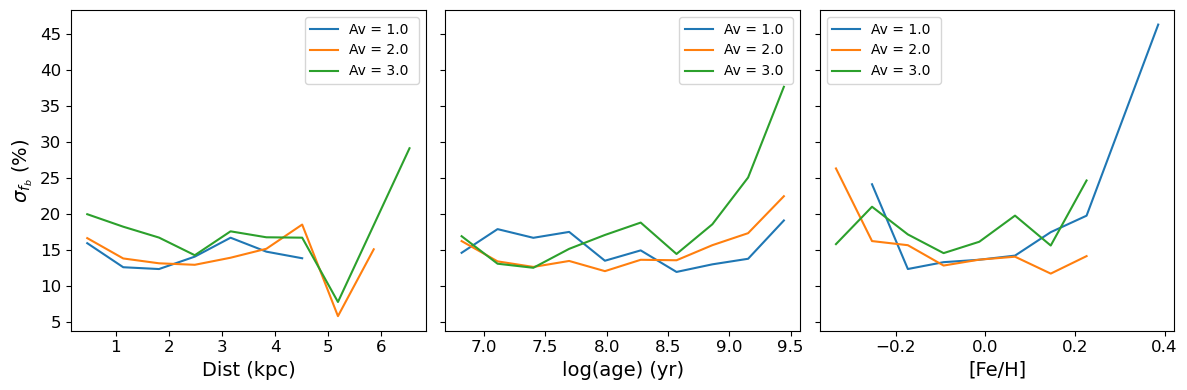

In [30]:
fig, axs = plt.subplots(1,3, figsize = (12,4), sharey=True)
aux = df.copy(deep=True)

# Agrupamento por faixas de extinção Av
aux['Av_group'] = pd.cut(aux['Av'], bins=[0, 1.0, 2.0, 3.0], labels=['Av = 1.0 ', 'Av = 2.0', 'Av = 3.0',])

# Divide a variável 'dist' (distância) em 10 faixas
aux['dist_bin'] = pd.cut(aux['dist'], bins=10)
aux['dist_center'] = aux['dist_bin'].apply(lambda x: x.mid)

# Agrupa por faixa de dist e grupo de Av, calcula média de e_bin_frac
grouped = aux.groupby(['Av_group', 'dist_center'])['e_bin_frac'].agg(['mean',]).reset_index()
sns.lineplot(data=grouped, x='dist_center', y=grouped['mean']*100, hue='Av_group', ax= axs[0])
axs[0].set_xlabel(r'Dist (kpc)', fontdict=font)



aux['age_bin'] = pd.cut(aux['age'], bins=10)
aux['age_center'] = aux['age_bin'].apply(lambda x: x.mid)

grouped = aux.groupby(['Av_group', 'age_center'])['e_bin_frac'].agg(['mean',]).reset_index()
grouped['mean'] = grouped['mean']*100


sns.lineplot(data=grouped, x='age_center', y=grouped['mean'], hue='Av_group', ax= axs[1])
axs[1].set_xlabel(r'log(age) (yr)', fontdict=font)

aux['FeH_bin'] = pd.cut(aux['FeH'], bins=10)
aux['FeH_center'] = aux['FeH_bin'].apply(lambda x: x.mid)


grouped = aux.groupby(['Av_group', 'FeH_center'])['e_bin_frac'].agg(['mean',]).reset_index()

sns.lineplot(data=grouped, x='FeH_center', y=grouped['mean']*100, hue='Av_group', ax= axs[2])
axs[2].set_xlabel(r'[Fe/H]', fontdict=font)

axs[0].set_ylabel(r'$\sigma_{f_b}$ (%)', fontdict= font)
axs[1].set_ylabel(r'$\sigma_{f_b}$ (%)', fontdict= font)
axs[2].set_ylabel(r'$\sigma_{f_b}$ (%)', fontdict= font)

for ax in axs:
    ax.tick_params(labelsize=labelsize)
    ax.legend(fontsize=10)

plt.tight_layout()
#plt.savefig('err_fb.png',bbox_inches='tight', dpi=300)
plt.show()


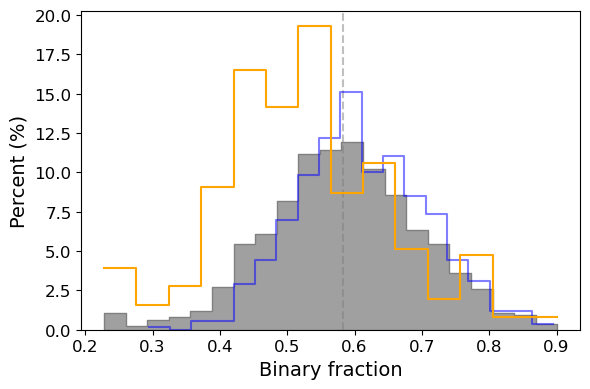

In [31]:
fig, ax= plt.subplots(figsize= (6,4))
sns.histplot(data=df, x='bin_frac', stat='percent', element='step', color='gray',)
plt.axvline(df.bin_frac.median(), ls='--', c='gray', alpha=0.5)
sns.histplot(data=df[df.Av>1], x='bin_frac', stat='percent', element='step', color='blue', fill = False, alpha=0.5)
sns.histplot(data=df[df.Av<=1], x='bin_frac', stat='percent', element='step', color='orange', fill = False,)

plt.xlabel('Binary fraction', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
ax.tick_params(labelsize=12)
plt.tight_layout()
#plt.savefig('dist_fb.png',  dpi=300)
plt.show()


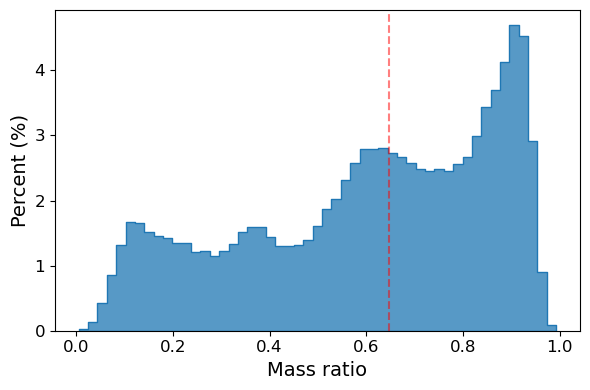

In [55]:
#q= []
#for cluster in df.index:
#    cluster_data = pd.read_csv(path+cluster+'.csv')
#    q.append(cluster_data[cluster_data['q']>0]['q'].values)
    
    
fig, ax= plt.subplots(figsize= (6,4))
sns.histplot(x=np.concatenate(q), stat='percent', element='step',)
plt.axvline(np.median(np.concatenate(q)), ls='--', c='r', alpha=0.5)

plt.xlabel('Mass ratio', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
ax.tick_params(labelsize=labelsize)
plt.tight_layout()
#plt.savefig('dist_mass_ratio.png',  dpi=300)
plt.show()